In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
import torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np
from collections import defaultdict
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
from PIL import Image
from functools import lru_cache  # Untuk optimasi cache

In [2]:
# Mapping baru untuk biner
binary_label_mapping = {
    255: 1,   # "unlabeled" (dihitung sebagai non-wooded)
    254: 1,   # "none"
    0: 0,     # "wooded" (kelas utama)
    1: 1,     # "agricultural"
    2: 1,     # "residential"
    3: 1,     # "industrial"
    4: 1,     # "commercial"
    5: 1,     # "recreation"
    6: 1,     # "airport"
    7: 1,     # "quarry"
    8: 1,     # "military"
    9: 1,     # "desert_sand"
    10: 1,    # "mountain_rock"
    11: 1     # "other_natural"
}

In [3]:
# Ubah mapping biner untuk wooded dan non-wooded
def apply_binary_label_mapping(label_array, binary_label_mapping):
    # Membuat salinan array label dan menerapkan label biner
    binary_label_array = np.copy(label_array)
    binary_label_array[label_array == 0] = 1  # "wooded" diubah menjadi 1
    binary_label_array[label_array != 0] = 0  # Selain "wooded" menjadi 0 (non-wooded)
    
    return binary_label_array

In [4]:
class SentinelBinaryDataset(Dataset):
    def __init__(self, image_dir, label_dir, metadata_path, transform=None, bad_percent_threshold=0.05):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.metadata_path = metadata_path
        self.binary_label_mapping = binary_label_mapping
        self.transform = transform
        self.bad_percent_threshold = bad_percent_threshold
        self.image_paths = []
        self.label_paths = []

        # Memuat dan menyaring path citra dan label
        self._load_image_label_paths()
        self.filter_tropical_regions()
        self.filter_by_class_threshold()

    def _load_image_label_paths(self):
        """
        Finds image and label paths based on folder structure and bad_percent filtering.
        """
        for root, dirs, files in os.walk(self.image_dir):
            s2a_files = [f for f in files if f.startswith('S2A') and f.endswith('.npz')]
            s2b_files = [f for f in files if f.startswith('S2B') and f.endswith('.npz')]

            for s2a_file, s2b_file in zip(s2a_files, s2b_files):
                s2a_path = os.path.join(root, s2a_file)
                s2a_data = np.load(s2a_path)

                if 'bad_percent' in s2a_data and s2a_data['bad_percent'] <= self.bad_percent_threshold:
                    folder_code = os.path.relpath(root, self.image_dir)
                    label_path = os.path.join(self.label_dir, f"{folder_code}.png")

                    if os.path.exists(label_path):
                        self.image_paths.append(s2a_path)
                        self.label_paths.append(label_path)
                    else:
                        print(f"Label not found for {folder_code}")

    def filter_by_class_threshold(self):
        """
        Filter images and labels with 'wooded' class ratio above a given threshold.
        """
        valid_image_paths = []
        valid_label_paths = []

        for image_path, label_path in zip(self.image_paths, self.label_paths):
            label = np.array(Image.open(label_path))
            wooded_ratio = np.sum(label == 0) / label.size

            if wooded_ratio >= 0.05:
                valid_image_paths.append(image_path)
                valid_label_paths.append(label_path)

        self.image_paths = valid_image_paths
        self.label_paths = valid_label_paths

    def filter_tropical_regions(self):
        metadata = pd.read_csv(self.metadata_path)
        tropical_metadata = metadata[(metadata['min_lat'] >= -23.5) & (metadata['max_lat'] <= 66.5)]
        tropical_cell_ids = set(tropical_metadata['cell_id'].astype(str))

        self.image_paths = [
            img_path for img_path in self.image_paths
            if any(cell_id in img_path for cell_id in tropical_cell_ids)
        ]
        self.label_paths = [
            lbl_path for lbl_path in self.label_paths
            if any(cell_id in lbl_path for cell_id in tropical_cell_ids)
        ]

    @lru_cache(maxsize=None)
    def load_image_data(self, image_path):
        """
        Load and cache image data from npz file.
        """
        image_data = np.load(image_path)
        if 'gsd_10' in image_data:
            return image_data['gsd_10']
        else:
            raise ValueError(f"No 10m band data found in {image_path}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = self.load_image_data(image_path)

        label_path = self.label_paths[idx]
        label = Image.open(label_path)
        label = apply_binary_label_mapping(np.array(label)[:,:,0], self.binary_label_mapping)

        if self.transform:
            image, label = self.transform(image, label)

        image = image.astype(np.float32) / 255.0
        image = torch.tensor(image).permute(2, 0, 1)
        label = torch.tensor(label).long()

        return image, label
    
    def visualize_random_sample(self):
        """
        Visualize a random image and its corresponding binary label.
        """
        # Randomly select an index from the dataset
        idx = random.randint(0, len(self.image_paths) - 1)
        # Get the image and label at the random index
        image, label = self.__getitem__(idx)

        # Permute the image from [C, H, W] to [H, W, C] for visualization
        image_np = image.permute(1, 2, 0).numpy()

        # Normalize image (if necessary) for proper visualization
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
        
        # Convert binary label to RGB for visualization
        label_rgb = np.zeros((label.shape[0], label.shape[1], 3))  # Placeholder for RGB
        label_rgb[label == 1] = np.array([0, 1, 0])  # "wooded" in green
        label_rgb[label == 0] = np.array([0.5, 0.5, 0.5])  # "non-wooded" in gray
        
        # Plotting image and label side by side
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # Image plot (first three bands for RGB approximation)
        axes[0].imshow(image_np[:, :, :3])
        axes[0].set_title("Image (RGB Approximation)")
        axes[0].axis('off')  # Turn off axis ticks
        
        # Label plot (binary)
        axes[1].imshow(label_rgb)
        axes[1].set_title("Label (Binary)")
        axes[1].axis('off')  # Turn off axis ticks

    plt.show()

In [5]:
# Path ke direktori dan file yang dibutuhkan
image_dir = r"D:\\FOLU NET SINK 2030\\osm_sentinel_imagery"  # Path direktori gambar
label_dir = r"D:\\FOLU NET SINK 2030\\osm_label_images_v10"  # Path direktori label
metadata_path = r"D:\\FOLU NET SINK 2030\\spatial_cell_info.csv"  # Path file metadata CSV

# Inisialisasi dataset
dataset = SentinelBinaryDataset(
    image_dir=image_dir,
    label_dir=label_dir,
    metadata_path=metadata_path,
    transform=None,  # Tambahkan transformasi jika diperlukan
    bad_percent_threshold=0.05  # Sesuaikan sesuai kebutuhan
)

Label not found for 08VMK\121188092
Label not found for 08VMK\121287851
Label not found for 08VMK\121298906
Label not found for 10UCF\118605868
Label not found for 10UCF\118605877
Label not found for 10UCF\118618122
Label not found for 10UCF\118618130
Label not found for 10UCF\118630378
Label not found for 10UCF\118654854
Label not found for 10UCF\118667088
Label not found for 10UCF\118715972
Label not found for 10UCF\118752579
Label not found for 10UCF\118752580
Label not found for 10UCF\118752581
Label not found for 10UCF\118764772
Label not found for 10UCF\118764773
Label not found for 10UCF\118971319
Label not found for 10UCF\119164321
Label not found for 11UQU\117291426
Label not found for 11UQU\117304208
Label not found for 11UQU\117342528
Label not found for 11UQU\117406293
Label not found for 11UQU\117533449
Label not found for 12RXQ\93089731
Label not found for 12RXQ\93089732
Label not found for 12RXQ\93108476
Label not found for 12RXQ\93108478
Label not found for 12RXQ\931084

In [6]:
# Jumlah data setelah filter
print("Jumlah data setelah filter:", len(dataset))

Jumlah data setelah filter: 7974


In [ ]:
# Fungsi menghitung ratio piksel per kelas
def calculate_class_ratios(dataset):
    class_counts = defaultdict(int)
    total_pixels = 0

    for _, label in dataset:
        # Hitung total piksel
        total_pixels += label.numel()

        # Hitung piksel per kelas
        unique, counts = torch.unique(label, return_counts=True)
        for u, c in zip(unique.tolist(), counts.tolist()):
            class_counts[u] += c

    # Hitung rasio setiap kelas
    class_ratios = {k: v / total_pixels for k, v in class_counts.items()}
    return class_counts, class_ratios

# Menghitung rasio kelas untuk memastikan filter
class_counts, class_ratios = calculate_class_ratios(dataset)
print("Jumlah piksel per kelas:", class_counts)
print("Rasio piksel per kelas:", class_ratios)

Jumlah piksel per kelas: defaultdict(<class 'int'>, {0: 143932103, 1: 150021433})
Rasio piksel per kelas: {0: 0.4896423596687063, 1: 0.5103576403312937}


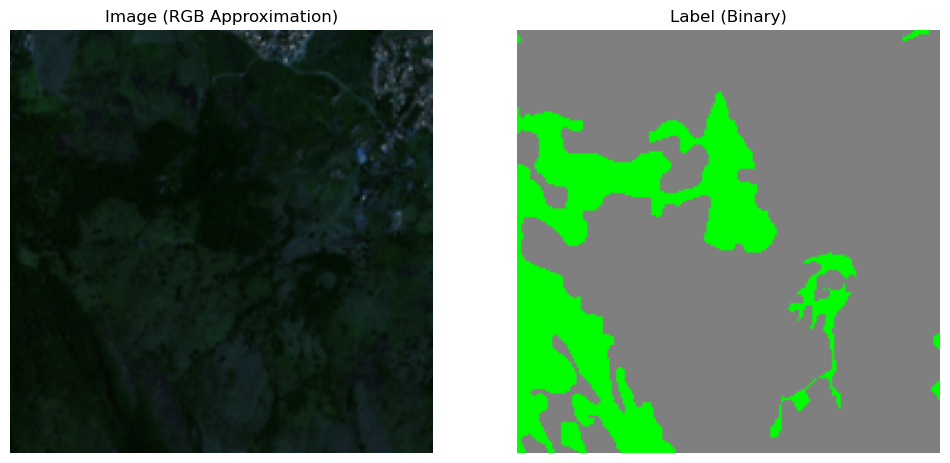

In [10]:
# Visualisasikan sampel acak
dataset.visualize_random_sample()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:


# Definisi arsitektur U-Net
class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):  # out_channels=1 untuk biner
        super(UNet, self).__init__()
        
        # Encoder
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)
        
        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)
        
        # Decoder
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)
        
        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)
        
        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)
        
        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)
        
        # Output layer dengan satu channel (untuk output biner)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(F.max_pool2d(enc1, 2))
        enc3 = self.encoder3(F.max_pool2d(enc2, 2))
        enc4 = self.encoder4(F.max_pool2d(enc3, 2))
        
        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool2d(enc4, 2))
        
        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        
        # Final output layer
        return self.final_conv(dec1)

In [13]:
# Fungsi IoU untuk biner
def iou(preds, labels):
    preds = (preds > 0.5).int()  # Konversi prediksi ke biner
    labels = labels.int()
    intersection = (preds & labels).sum().float()  # Hitung irisan
    union = (preds | labels).sum().float()  # Hitung gabungan
    iou_value = intersection / union if union > 0 else 0.0  # Menghitung IoU
    return iou_value

In [14]:
# Fungsi pelatihan dengan fungsi loss BCE
def train_model(model, train_loader, valid_loader, criterion, optimizer, device, num_epochs, early_stopping_patience):
    train_losses, valid_losses = [], []
    train_ious, valid_ious = [], []
    train_accuracies, valid_accuracies = [], []
    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Training loop
        model.train()
        train_loss, train_iou_total, train_correct, train_total = 0, 0, 0, 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.float().to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs.squeeze(1), labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.sigmoid(outputs.squeeze(1)) > 0.5
            train_iou_total += iou(preds.cpu(), labels.cpu()).item()

            # Calculate accuracy
            train_correct += (preds == labels.int()).sum().item()
            train_total += labels.numel()

        train_loss /= len(train_loader)
        train_iou = train_iou_total / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(train_loss)
        train_ious.append(train_iou)
        train_accuracies.append(train_acc)

        # Validation loop
        model.eval()
        valid_loss, valid_iou_total, valid_correct, valid_total = 0, 0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(valid_loader):
                images, labels = images.to(device), labels.float().to(device)
                outputs = model(images)
                loss = criterion(outputs.squeeze(1), labels)
                valid_loss += loss.item()
                
                preds = torch.sigmoid(outputs.squeeze(1)) > 0.5
                valid_iou_total += iou(preds.cpu(), labels.cpu()).item()

                # Calculate accuracy
                valid_correct += (preds == labels).sum().item()
                valid_total += labels.numel()

        valid_loss /= len(valid_loader)
        valid_iou = valid_iou_total / len(valid_loader)
        valid_acc = valid_correct / valid_total
        valid_losses.append(valid_loss)
        valid_ious.append(valid_iou)
        valid_accuracies.append(valid_acc)

        # Print progress
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Valid Loss: {valid_loss:.4f}, Valid IoU: {valid_iou:.4f}, Valid Acc: {valid_acc:.4f}")

        # Early stopping
        if valid_loss < best_loss:
            best_loss = valid_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model saved!")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered!")
            break
    
    # Save training and validation logs to CSV
    df = pd.DataFrame({
        'train_loss': train_losses,
        'valid_loss': valid_losses,
        'train_accuracy': train_accuracies,
        'valid_accuracy': valid_accuracies,
        'train_iou': train_ious,
        'valid_iou': valid_ious
    })
    df.to_csv('training_log.csv', index=False)
    return model

In [ ]:
# Fungsi Visualisasi hasil training
def visualize_training(df):
    epochs = len(df)
    plt.figure(figsize=(18, 6))

    #plot accuracy
    plt.subplot(1, 3, 1)
    plt.plot(range(epochs), df['train_accuracy'], label='Train Accuracy')
    plt.plot(range(epochs), df['valid_accuracy'], label='Valid Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title("Accuracy")
    plt.legend()

    # Plot loss
    plt.subplot(1, 3, 2)
    plt.plot(range(epochs), df['train_loss'], label='Train Loss')
    plt.plot(range(epochs), df['valid_loss'], label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Loss")
    plt.legend()

    # Plot IoU
    plt.subplot(1, 3, 3)
    plt.plot(range(epochs), df['train_iou'], label='Train IoU')
    plt.plot(range(epochs), df['valid_iou'], label='Valid IoU')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.title("IoU")
    plt.legend()

    plt.show()

In [16]:
# Setting hyperparameters dan memuat data
learning_rate = 0.0001
batch_size = 8
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [17]:
# Instantiate model, loss function dan optimizer
model = UNet(in_channels=4, out_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [18]:
# Callbacks yang digunakan (EarlyStopping sudah disertakan di fungsi train_model)
early_stopping_patience = 10  # Jika tidak ada peningkatan selama 5 epoch, training dihentikan.

In [19]:
# Training the model
model = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    early_stopping_patience=early_stopping_patience
)

Epoch 1/100


100%|██████████| 200/200 [00:12<00:00, 16.41it/s]


Train Loss: 0.6930, Train IoU: 0.5052, Train Acc: 0.5082
Valid Loss: 0.6928, Valid IoU: 0.5145, Valid Acc: 0.5134
Model saved!
Epoch 2/100


100%|██████████| 200/200 [00:12<00:00, 16.41it/s]


Train Loss: 0.6930, Train IoU: 0.5096, Train Acc: 0.5096
Valid Loss: 0.6928, Valid IoU: 0.5145, Valid Acc: 0.5134
Model saved!
Epoch 3/100


...

Train Loss: 0.3824, Train IoU: 0.7153, Train Acc: 0.8305
Valid Loss: 0.5127, Valid IoU: 0.6317, Valid Acc: 0.7689
Epoch 46/100


100%|██████████| 200/200 [00:12<00:00, 16.46it/s]


Train Loss: 0.3742, Train IoU: 0.7212, Train Acc: 0.8349
Valid Loss: 0.5399, Valid IoU: 0.6270, Valid Acc: 0.7670
Epoch 47/100


100%|██████████| 200/200 [00:12<00:00, 16.47it/s]


Train Loss: 0.3565, Train IoU: 0.7348, Train Acc: 0.8444
Valid Loss: 0.5479, Valid IoU: 0.6302, Valid Acc: 0.7702
Early stopping triggered!


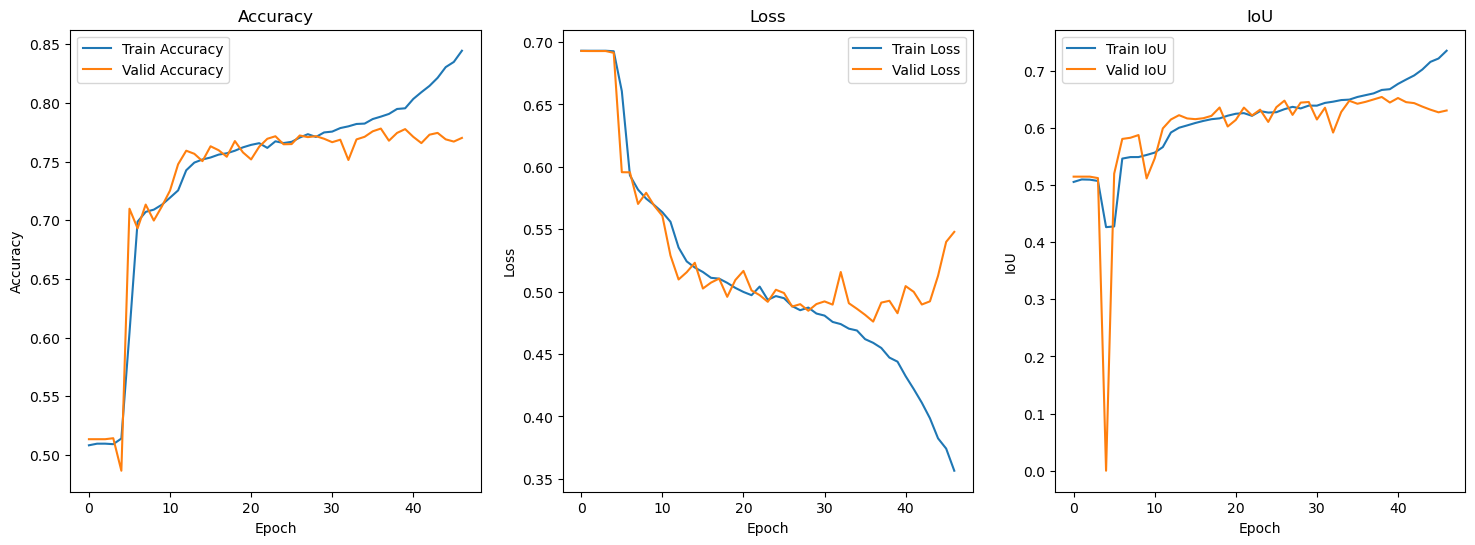

In [21]:
# Membaca file log hasil training
df = pd.read_csv('training_log.csv')

#visualisasi hasil training 
visualize_training(df)

## Prediksi

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colorbar import ColorbarBase

In [ ]:
# Load GeoTIFF image
def load_tif_image(file_path):
    with rasterio.open(file_path) as src:
        image = src.read([1, 2, 3, 4])  # Membaca seluruh band dari citra  
        image = np.moveaxis(image, 0, -1)  # Mengubah dimensi menjadi [H, W, C]
    return image

def predict_image(model, image_tensor):
    with torch.no_grad():
        # Pastikan tensor gambar tidak perlu dimuat ulang
        prediction = model(image_tensor)
        prediction = torch.sigmoid(prediction)  # Sigmoid untuk prediksi biner
        predicted_mask = (prediction > 0.5).squeeze().cpu().numpy()  # Threshold untuk biner
    return predicted_mask

# Visualize prediction
def visualize_prediction(image, prediction, colormap):
    # Plot RGB Image
    plt.figure(figsize=(12, 6))
    
    # Original Image in RGB
    plt.subplot(1, 2, 1)
    plt.imshow(image[:, :, :3])  # Display RGB channels
    plt.title("Original RGB Image")
    plt.axis("off")

    # Predicted Mask with Color Map
    plt.subplot(1, 2, 2)
    norm = BoundaryNorm([0, 1, 2], colormap.N)  # Normalize for binary classes (0, 1)
    mask_img = plt.imshow(prediction, cmap=colormap, norm=norm)
    plt.title("Predicted Mask")
    plt.axis("off")

    # Colorbar for Predicted Mask
    cbar = plt.colorbar(mask_img, orientation="vertical", ticks=[0, 1])
    cbar.ax.set_yticklabels(['Non-Wooded', 'Wooded'])  # Customize labels for classes
    cbar.set_label("Class Labels")
    plt.show()


# Save prediction to GeoTIFF
def save_prediction_to_tif(prediction, reference_path, output_path):
    with rasterio.open(reference_path) as src:
        meta = src.meta
        meta.update({
            'count': 1,  # Output mask hanya 1 channel
            'dtype': 'uint8'  # Simpan hasil prediksi sebagai uint8 (0 dan 1)
        })
        
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(prediction.astype('uint8'), 1)  # Simpan di channel pertama

In [24]:
# Ganti 'model_path.pth' dengan path model yang telah disimpan
# Memuat model yang telah disimpan
model = UNet()  # Sesuaikan dengan parameter model Anda
model.load_state_dict(torch.load('D:\\FOLU NET SINK 2030\\Script\\best_model.pth'))
model.eval()  # Set ke evaluasi mode

C:\Users\Intel 2\AppData\Local\Temp\ipykernel_18676\1962770412.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('D:\\FOLU NET SINK 2030\\

UNet(
  (encoder1): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (encoder3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (encoder4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Con

In [25]:
# Example usage
image_path = "D:\\FOLU NET SINK 2030\\filter_osm_sentinel_imagery\\image\\35197933.tif"
image = load_tif_image(image_path)

In [26]:
# Prepare image tensor
image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)  # (1, 4, H, W)

# Perform prediction
predicted_mask = predict_image(model, image_tensor)

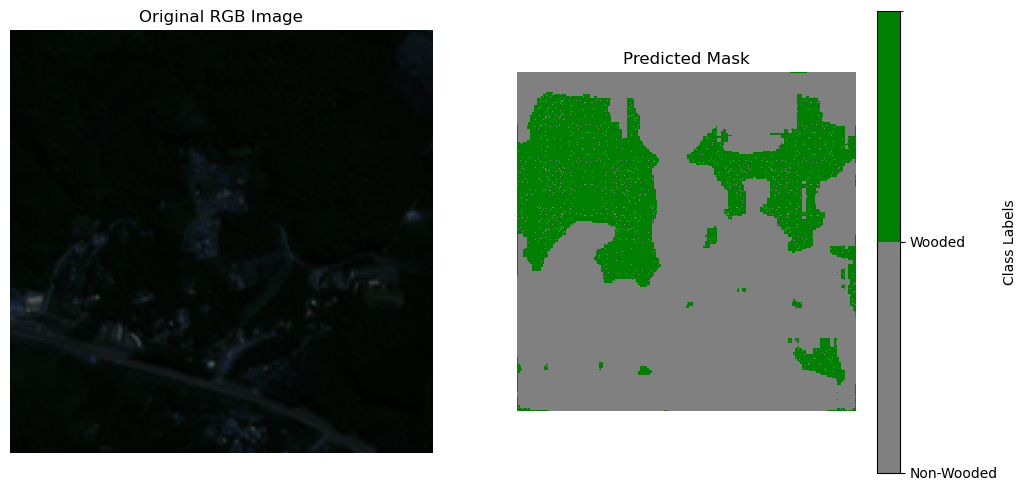

In [ ]:
# Define a custom colormap for visualization
colormap = ListedColormap(['gray', 'green'])  # Modify as needed for more classes

# Visualize the original image and prediction
visualize_prediction(image, predicted_mask, colormap)